# Example-28: SKIF

## Import & definitions

In [1]:
import matplotlib
from matplotlib import pyplot as plt
from matplotlib import colors
from matplotlib import colormaps
from matplotlib import gridspec

matplotlib.rcParams['text.usetex'] = True

In [2]:
# Import

import sys
sys.path.append('..')

from torch import Tensor
from numpy import ndarray as Array

import numpy
import torch

from harmonica.util import mod

from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.decomposition import Decomposition
from harmonica.model import Model
from harmonica.table import Table
from harmonica.twiss import Twiss

from harmonica.parameterization import twiss_phase_advance
from harmonica.parameterization import normal_to_wolski
from harmonica.parameterization import wolski_to_cs
from harmonica.parameterization import invariant
from harmonica.parameterization import parametric_normal

from harmonica.statistics import root_mean_square

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

import re

In [3]:
# Set data type and device

dtype = torch.float64
device = 'cpu'

## Model setup

In [4]:
# Load lodel

model = Model(path='../config/skif.yaml', model='uncoupled', dtype=dtype, device=device)

# Number of monitor and virtual locations
# Calibration errors are added to monitor locations, normal and skew quadrupole errors are added to virtual locations

print(model.monitor_count)
print(model.virtual_count)

224
753


In [4]:
lq = [model.name.index(name) for name in model.name if re.match(r'^(MA).*\.Q[F, D]', name)]
len(lq)

96

In [5]:
# Set full TbT length (full length is used for frequency estimation)

length:int = 2**10

In [6]:
# Set window function (frequency estimation) 

window:Window = Window.from_cosine(length, 1.0, dtype=dtype, device=device)

In [7]:
## Set data containers

tbt_x:Data = Data(model.monitor_count, window)
tbt_y:Data = Data(model.monitor_count, window)

In [8]:
# Set frequency containers

f_x:Frequency = Frequency(tbt_x)
f_y:Frequency = Frequency(tbt_y)

In [9]:
# Set decomposition containers

d_x:Decomposition = Decomposition(tbt_x)
d_y:Decomposition = Decomposition(tbt_y)

In [10]:
# Initialize zero focusing errors for all locations

kn:Tensor = torch.zeros(model.size, dtype=dtype, device=device)
ks:Tensor = torch.zeros(model.size, dtype=dtype, device=device)

In [11]:
# Set weak focusing errors at all stand alone quadrupoles

kn[lq] = 5.0E-3*torch.randn(len(lq), dtype=dtype, device=device)
ks[lq] = 1.0E-4*torch.randn(len(lq), dtype=dtype, device=device)

In [12]:
# Compute twiss parametes with quadrupole errors (beam frame twiss parameters)

model.make_error(kn, ks, length=0.0)
model.make_transport(error=True, exact=False)
model.make_twiss()

True

In [13]:
# Compute phase advanced between monitors  (beam frame twiss parameters)

nux, nuy = model.out_tune_fractional
mux, muy = mod(model.out_advance.roll(1, 0).cumsum(0)[model.monitor_index].T, 2.0*numpy.pi)
mux, _ = Decomposition.phase_adjacent(nux, mux)
muy, _ = Decomposition.phase_adjacent(nuy, muy)

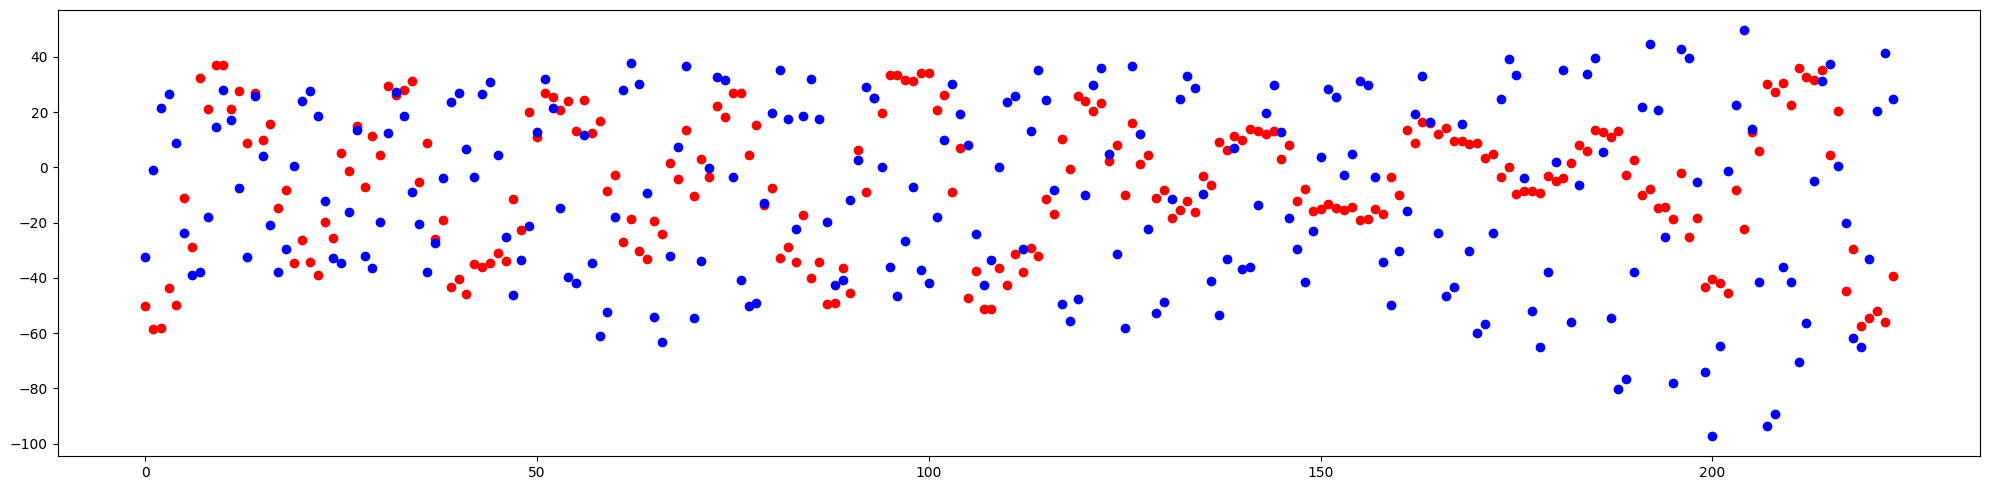

25.07
34.85


In [14]:
# Compare with model

Ax, bx, Ay, by = model.out_cs[model.monitor_index].T

plt.figure(figsize=(20, 5))
plt.scatter(range(model.monitor_count), 100*(((model.bx[model.monitor_index] - bx)/model.bx[model.monitor_index])).cpu().numpy(), color='red')
plt.scatter(range(model.monitor_count), 100*(((model.by[model.monitor_index] - by)/model.by[model.monitor_index])).cpu().numpy(), color='blue')
plt.tight_layout()
plt.show()

print(f'{100*root_mean_square((model.bx[model.monitor_index] - bx)/model.bx[model.monitor_index]).item():.2f}')
print(f'{100*root_mean_square((model.by[model.monitor_index] - by)/model.by[model.monitor_index]).item():.2f}')

In [15]:
# Set twiss parameters

normal = model.out_normal[model.monitor_index]

n11 = normal[:, 0, 0]
n12 = normal[:, 0, 1]
n13 = normal[:, 0, 2]
n14 = normal[:, 0, 3]

n21 = normal[:, 1, 0]
n22 = normal[:, 1, 1]
n23 = normal[:, 1, 2]
n24 = normal[:, 1, 3]

n31 = normal[:, 2, 0]
n32 = normal[:, 2, 1]
n33 = normal[:, 2, 2]
n34 = normal[:, 2, 3]

n41 = normal[:, 3, 0]
n42 = normal[:, 3, 1]
n43 = normal[:, 3, 2]
n44 = normal[:, 3, 3]

## Harmonic decomposition

In [16]:
# Generate TbT signals at monitors (beam frame)

point = torch.tensor([0.00075, 0.0, 0.000375, 0.0], dtype=dtype, device=device)
qx, px, qy, py =  model.make_trajectory(point, length, error=True, transport=True)[model.monitor_index].permute(-1, 0, 1)

print(qx.shape)
print(px.shape)
print(qy.shape)
print(py.shape)

torch.Size([224, 1024])
torch.Size([224, 1024])
torch.Size([224, 1024])
torch.Size([224, 1024])


In [17]:
# Set noise values for each monitor location 

on = True
s_x = on*1.0E-6*(1.0 + 1.0*torch.rand(model.monitor_count, dtype=dtype, device=device))
s_y = on*1.0E-6*(1.0 + 1.0*torch.rand(model.monitor_count, dtype=dtype, device=device))

In [18]:
# Compute exact invariants

ix, iy = torch.vmap(invariant)(normal, torch.stack([qx, px, qy, py]).permute(1, -1, 0)).swapaxes(0, 1).mean(-1)

print(ix.mean())
print(iy.mean())

tensor(1.3972e-08, dtype=torch.float64)
tensor(1.8755e-08, dtype=torch.float64)


In [19]:
# Perform harmonic decmposition of TbT data

In [20]:
# Set data containers

tbt_x.data = qx.clone()
tbt_x.work = qx.clone()
tbt_x.add_noise(s_x)
tbt_x.data = tbt_x.work.clone()
tbt_x.reset()

tbt_y.data = qy.clone()
tbt_y.work = qy.clone()
tbt_y.add_noise(s_y)
tbt_y.data = tbt_y.work.clone()
tbt_y.reset()

In [21]:
# Compute frequencies (horizontal and vertical)

tbt_x.window_remove_mean()
tbt_x.window_apply()
f_x('parabola')
tbt_x.reset()

tbt_y.window_remove_mean()
tbt_y.window_apply()
f_y('parabola')
tbt_y.reset()

nux, sigma_nux = 1.0 - f_x.frequency.mean(),  f_x.frequency.std()
nuy, sigma_nuy = 1.0 - f_y.frequency.mean(),  f_y.frequency.std()

print(sigma_nux)
print(sigma_nuy)

tensor(1.2686e-07, dtype=torch.float64)
tensor(1.5360e-07, dtype=torch.float64)


In [22]:
# Compute amplitudes and phases (horizontal and vertical)

axx, sigma_axx, _ = d_x.harmonic_amplitude(nux, length=128, order=1.0, error=True, sigma_frequency=sigma_nux, shift=True, count=64, step=4)
fxx, sigma_fxx, _ = d_x.harmonic_phase(nux, length=256, order=1.0, error=True, sigma_frequency=sigma_nux, shift=True, count=64, step=4)
ayy, sigma_ayy, _ = d_y.harmonic_amplitude(nuy, length=128, order=1.0, error=True, sigma_frequency=sigma_nux, shift=True, count=64, step=4)
fyy, sigma_fyy, _ = d_y.harmonic_phase(nuy, length=256, order=1.0, error=True, sigma_frequency=sigma_nux, shift=True, count=64, step=4)

axy, _, _ = d_x.harmonic_amplitude(nuy, length=128, order=1.0, error=True, sigma_frequency=sigma_nux, shift=True, count=64, step=4)
fxy, _, _ = d_x.harmonic_phase(nuy, length=256, order=1.0, error=True, sigma_frequency=sigma_nux, shift=True, count=64, step=4)
ayx, _, _ = d_y.harmonic_amplitude(nux, length=128, order=1.0, error=True, sigma_frequency=sigma_nux, shift=True, count=64, step=4)
fyx, _, _ = d_y.harmonic_phase(nux, length=256, order=1.0, error=True, sigma_frequency=sigma_nux, shift=True, count=64, step=4)

In [23]:
# Set table

table = Table(model.monitor_name,
              nux, nuy,
              axx, ayy, fxx, fyy,
              sigma_nux, sigma_nuy,
              sigma_axx, sigma_ayy, sigma_fxx, sigma_fyy,
              x=qx,
              y=qy,
              dtype=dtype,
              device=device)

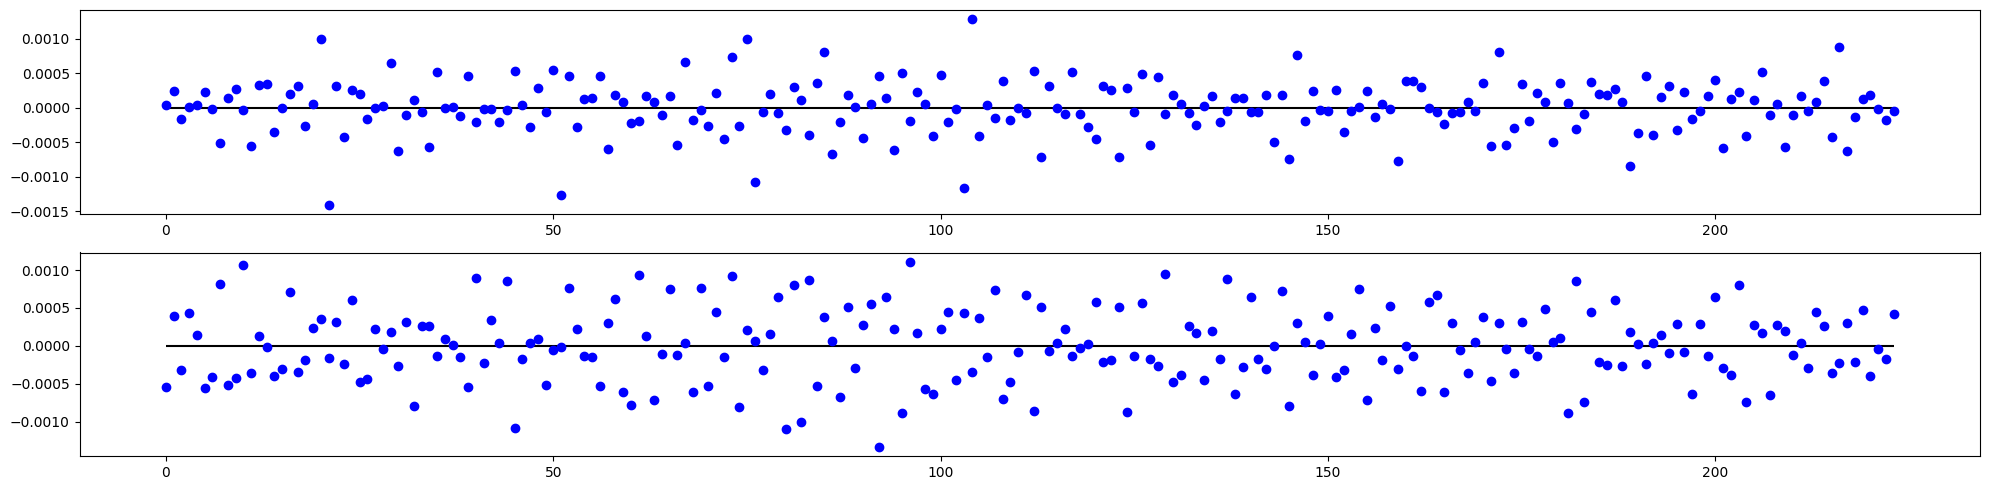

In [24]:
# Compare phase advance 

plt.figure(figsize=(20, 5))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), (mux - table.phase_x.cpu().numpy()), fmt=' ', marker='o', color='blue')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), (muy - table.phase_y.cpu().numpy()), fmt=' ', marker='o', color='blue')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
plt.tight_layout()
plt.show()

## Twiss from amplitude & phase

In [25]:
# Set twiss

twiss = Twiss(model, table, limit=3)

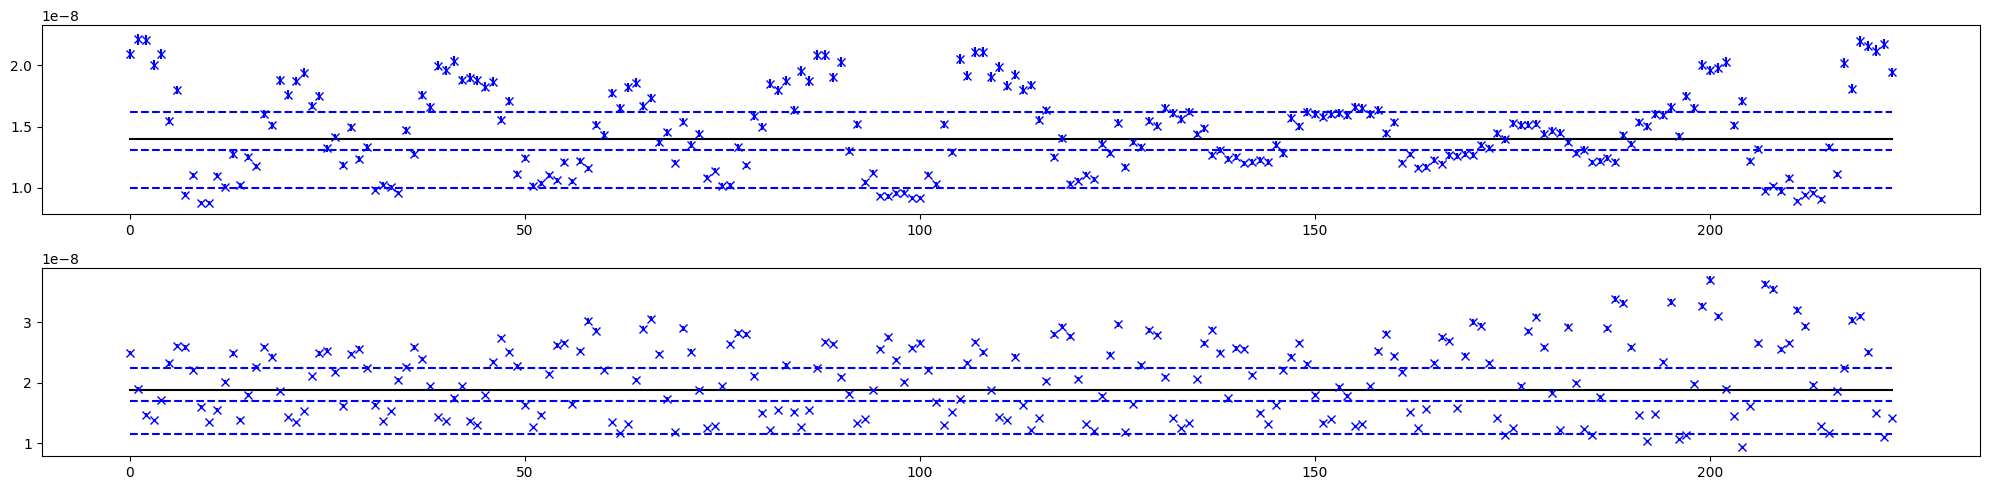

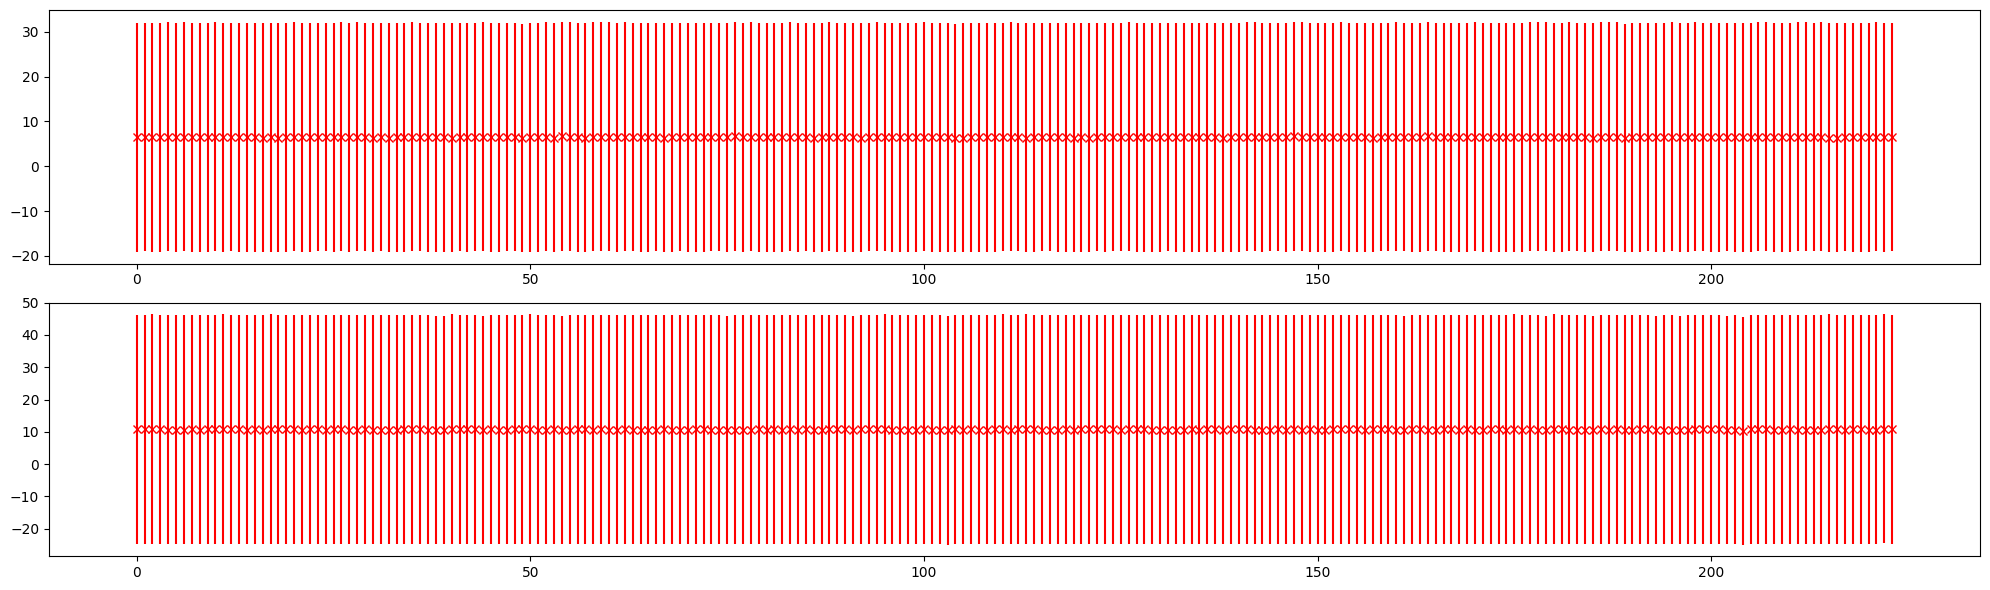

tensor(6.4957, dtype=torch.float64)
tensor(10.7110, dtype=torch.float64)



In [26]:
# Estimate twiss from amplitude (model beta functions are used to estimate invariants)

twiss.get_action()
twiss.get_twiss_from_amplitude()

# Compare estimated invariants

plt.figure(figsize=(20, 5))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), ix.cpu().numpy(), fmt='-', color='black')
ax.errorbar(range(model.monitor_count), twiss.action['jx'].cpu().numpy(), yerr=twiss.action['sigma_jx'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jx'] - twiss.action['spread_jx']).cpu().numpy(), twiss.action['center_jx'].cpu().numpy(), (twiss.action['center_jx'] + twiss.action['spread_jx']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), iy.cpu().numpy(), fmt='-', color='black')
ax.errorbar(range(model.monitor_count), twiss.action['jy'].cpu().numpy(), yerr=twiss.action['sigma_jy'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jy'] - twiss.action['spread_jy']).cpu().numpy(), twiss.action['center_jy'].cpu().numpy(), (twiss.action['center_jy'] + twiss.action['spread_jy']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
plt.tight_layout()
plt.show()

# Compare estimated twiss

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by)/by).cpu().numpy(), yerr=100/by*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx)/bx)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by)/by)))
print()

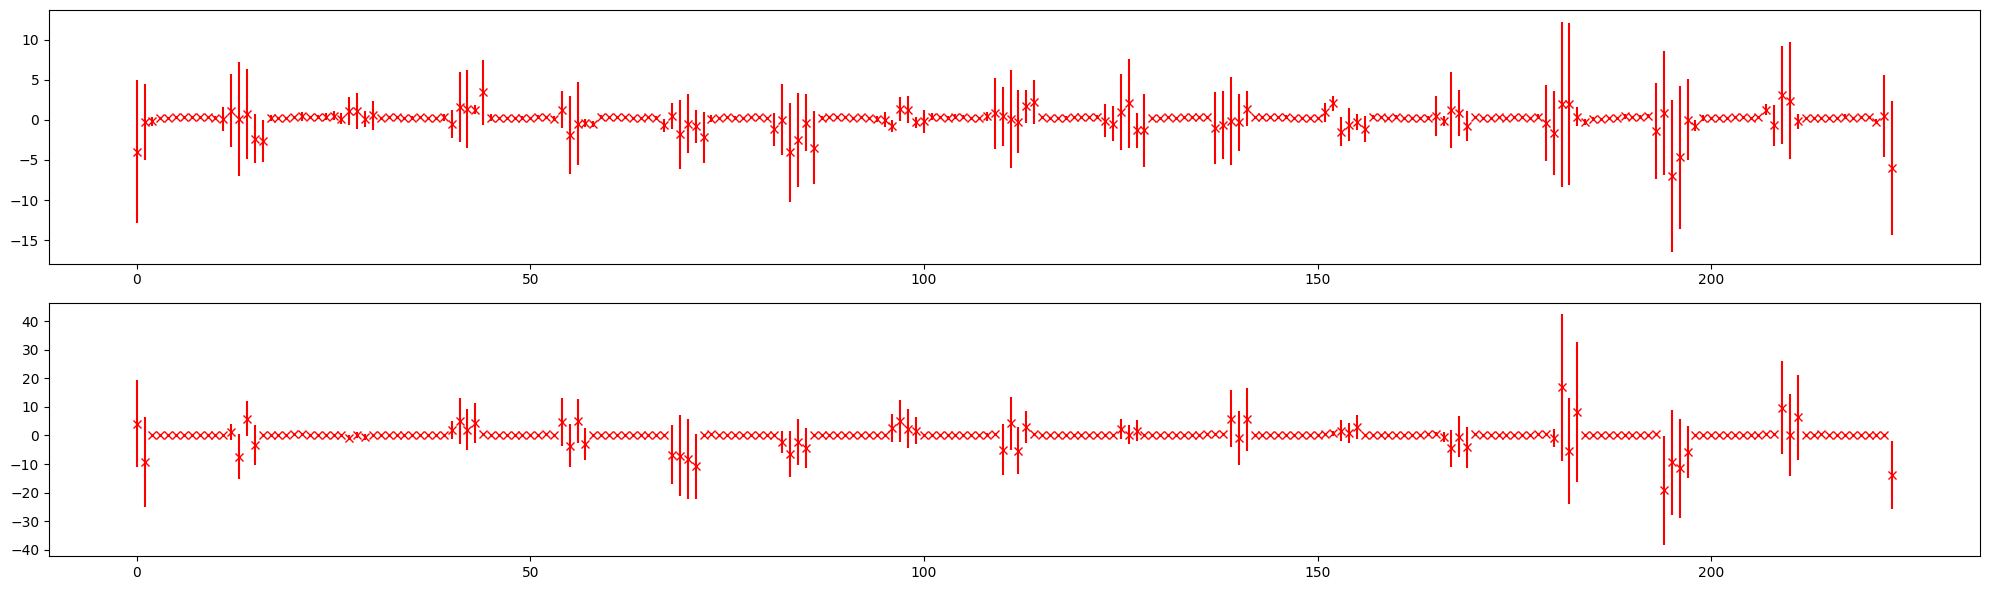

tensor(1.1392, dtype=torch.float64)
tensor(3.1780, dtype=torch.float64)



In [27]:
# Estimate twiss from phase

twiss.phase_virtual()
twiss.get_twiss_from_phase()
mask_x = twiss.filter_twiss(plane='x', phase={'use': True, 'threshold': 10.0}, model={'use': False, 'threshold': 0.5}, value={'use': False, 'threshold': 1.0}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
mask_y = twiss.filter_twiss(plane='y', phase={'use': True, 'threshold': 10.0}, model={'use': False, 'threshold': 0.5}, value={'use': False, 'threshold': 1.0}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
_ = twiss.process_twiss(plane='x', mask=mask_x, weight=True)
_ = twiss.process_twiss(plane='y', mask=mask_y, weight=True)

# Compare estimated twiss

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.bx[model.monitor_index] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.sigma_bx[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.by[model.monitor_index] - by)/by).cpu().numpy(), yerr=100/by*twiss.sigma_by[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((twiss.bx[model.monitor_index] - bx)/bx)))
print(root_mean_square(100*((twiss.by[model.monitor_index] - by)/by)))
print()

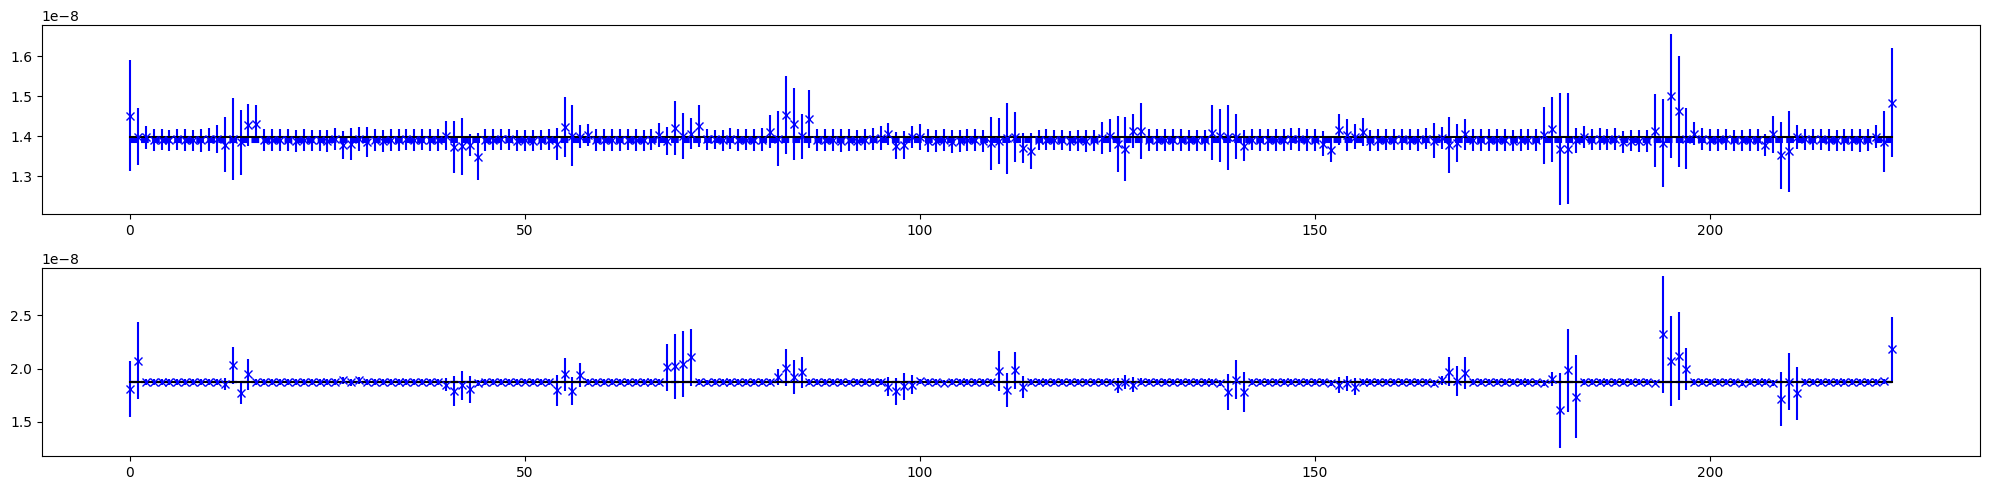

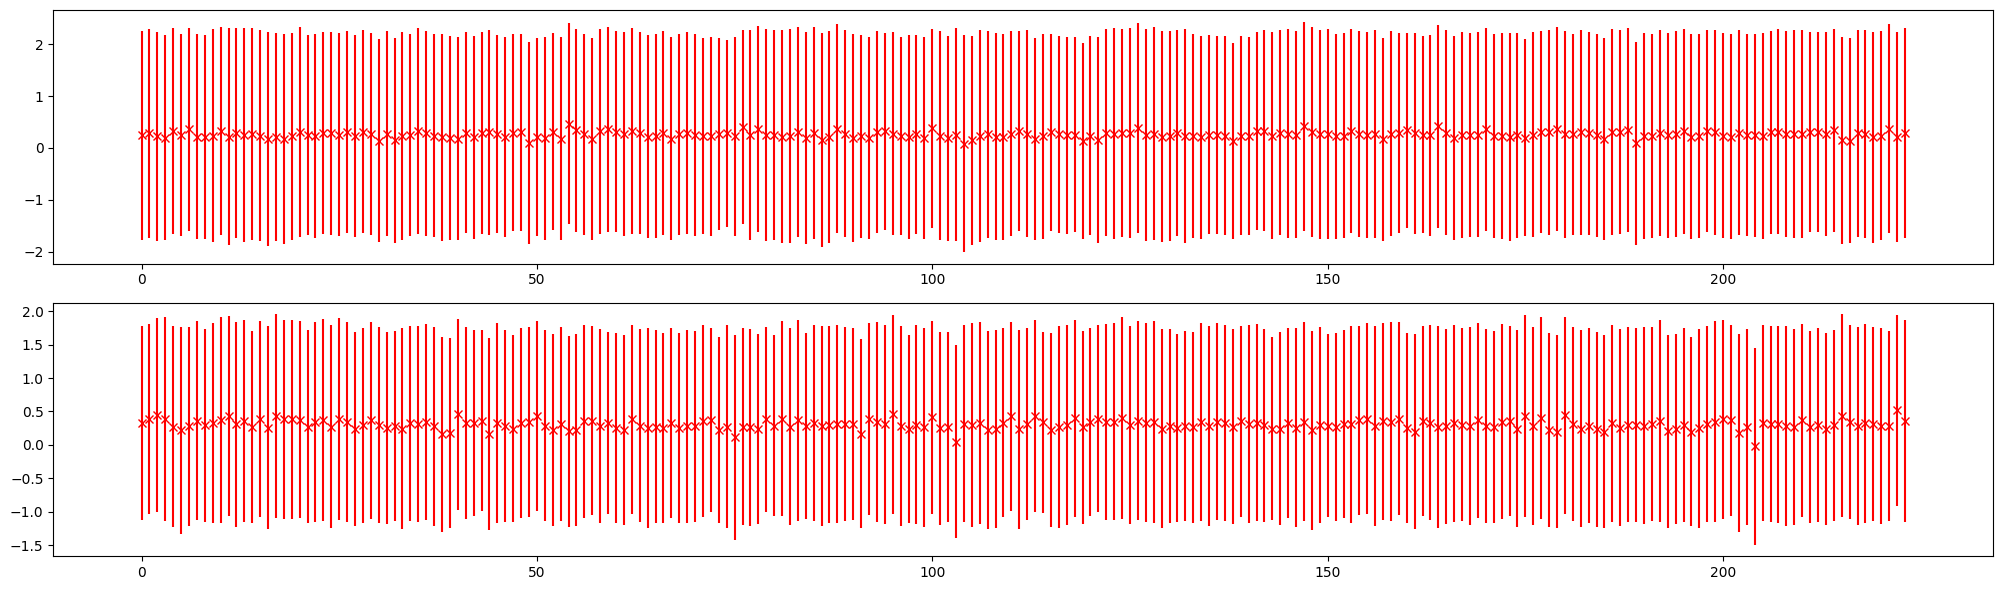

tensor(0.2649, dtype=torch.float64)
tensor(0.3112, dtype=torch.float64)



In [28]:
# Estimate twiss from amplitude (use twiss from phase for action estimation)

twiss.get_action(bx=twiss.bx[model.monitor_index], by=twiss.by[model.monitor_index], sigma_bx=twiss.sigma_bx[model.monitor_index], sigma_by=twiss.sigma_by[model.monitor_index])
twiss.get_twiss_from_amplitude()

# Compare estimated invariants

plt.figure(figsize=(20, 5))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), ix.cpu().numpy(), fmt='-', color='black')
ax.errorbar(range(model.monitor_count), twiss.action['jx'].cpu().numpy(), yerr=twiss.action['sigma_jx'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jx'] - twiss.action['spread_jx']).cpu().numpy(), twiss.action['center_jx'].cpu().numpy(), (twiss.action['center_jx'] + twiss.action['spread_jx']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), iy.cpu().numpy(), fmt='-', color='black')
ax.errorbar(range(model.monitor_count), twiss.action['jy'].cpu().numpy(), yerr=twiss.action['sigma_jy'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jy'] - twiss.action['spread_jy']).cpu().numpy(), twiss.action['center_jy'].cpu().numpy(), (twiss.action['center_jy'] + twiss.action['spread_jy']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
plt.tight_layout()
plt.show()

# Compare estimated twiss

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by)/by).cpu().numpy(), yerr=100/by*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx)/bx)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by)/by)))
print()

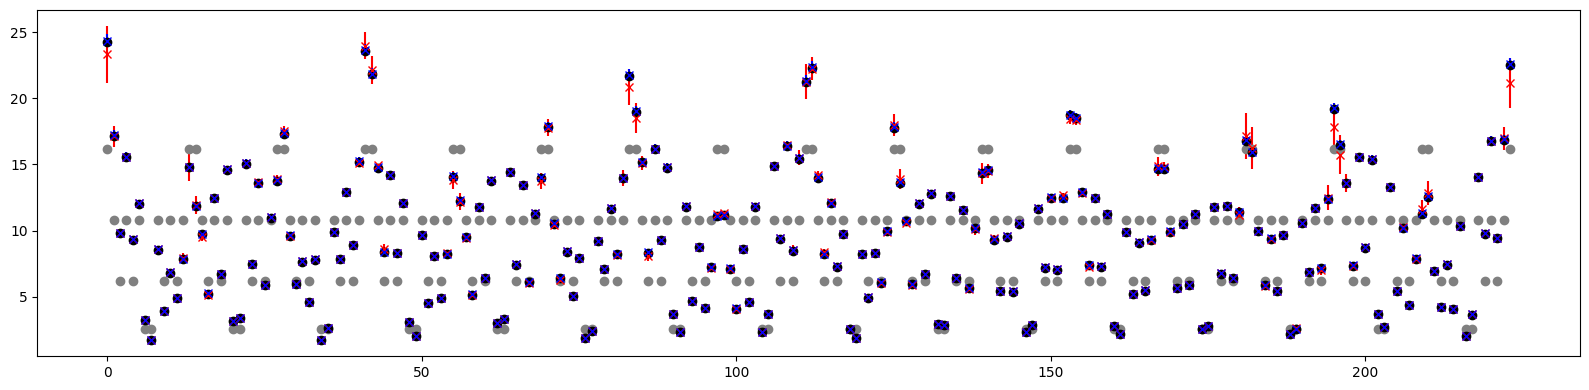

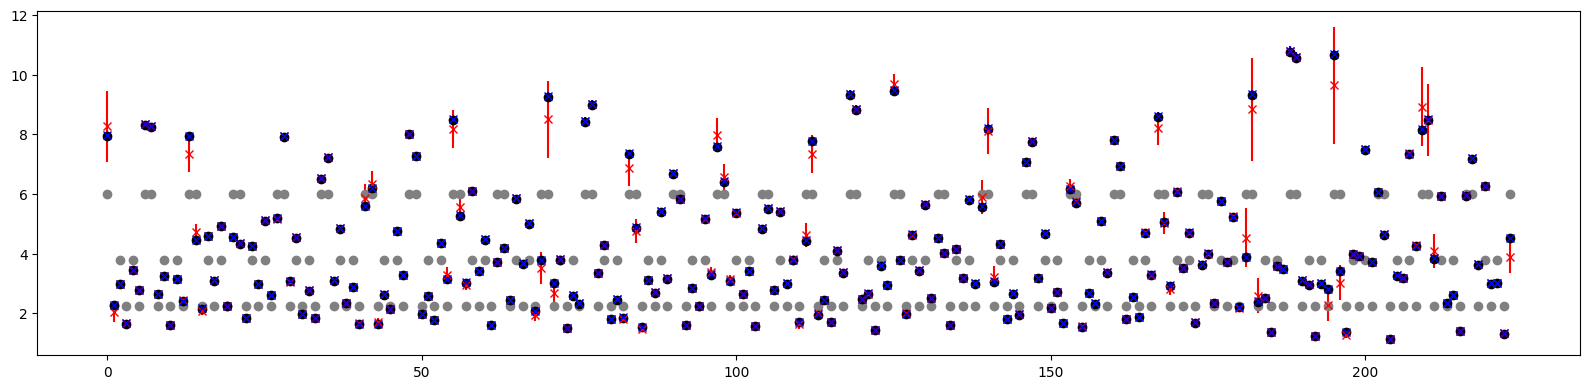

In [29]:
# FIG-1: MEASURED VS HIDDEN TWISS FROM AMPLITUDE AND PHASE

# |beta|
# |beta|

plt.figure(figsize=(16, 4))
plt.errorbar(range(model.monitor_count), model.bx[model.monitor_index], fmt=' ', color='gray', marker='o', ms=6)
plt.errorbar(range(model.monitor_count), bx, fmt=' ', color='black', marker='o', ms=6)
plt.errorbar(range(model.monitor_count), twiss.bx[model.monitor_index], yerr=twiss.sigma_bx[model.monitor_index], fmt=' ', color='red', marker='x', ms=6)
plt.errorbar(range(model.monitor_count), twiss.data_amplitude['bx'], yerr=twiss.data_amplitude['sigma_bx'], fmt=' ', color='blue', marker='x', ms=6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 4))
plt.errorbar(range(model.monitor_count), model.by[model.monitor_index], fmt=' ', color='gray', marker='o', ms=6)
plt.errorbar(range(model.monitor_count), by, fmt=' ', color='black', marker='o', ms=6)
plt.errorbar(range(model.monitor_count), twiss.by[model.monitor_index], yerr=twiss.sigma_by[model.monitor_index], fmt=' ', color='red', marker='x', ms=6)
plt.errorbar(range(model.monitor_count), twiss.data_amplitude['by'], yerr=twiss.data_amplitude['sigma_by'], fmt=' ', color='blue', marker='x', ms=6)
plt.tight_layout()
plt.show()

In [ ]:
model.monitor_index

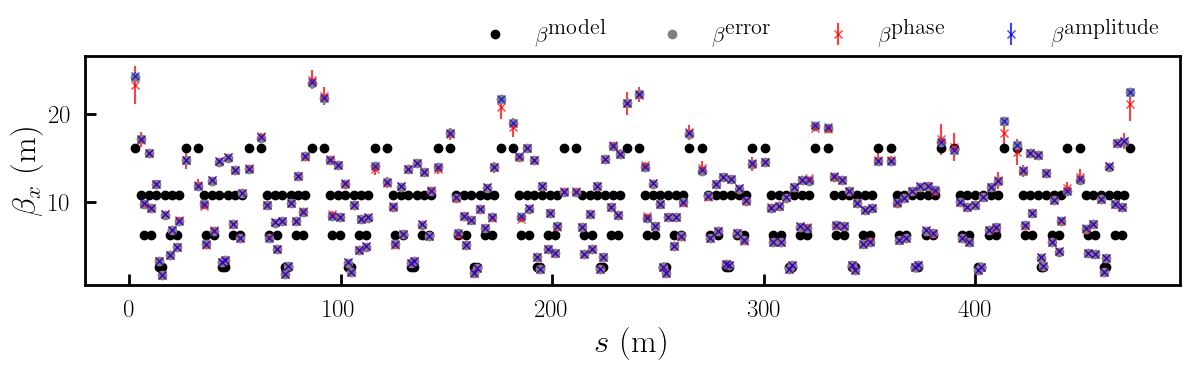

In [98]:
_, ax = plt.subplots(figsize=(12, 4))

ax.errorbar(model.time[model.monitor_index], model.bx[model.monitor_index], fmt=' ', color='black', marker='o', ms=6, label=r'$\beta^\textrm{model}$')
ax.errorbar(model.time[model.monitor_index], bx, fmt=' ', color='gray', marker='o', ms=6, label=r'$\beta^\textrm{error}$')
ax.errorbar(model.time[model.monitor_index], twiss.bx[model.monitor_index], yerr=twiss.sigma_bx[model.monitor_index], fmt=' ', color='red', marker='x', ms=6, alpha=0.75, label=r'$\beta^\textrm{phase}$')
ax.errorbar(model.time[model.monitor_index], twiss.data_amplitude['bx'], yerr=twiss.data_amplitude['sigma_bx'], fmt=' ', color='blue', marker='x', ms=6, alpha=0.75, label=r'$\beta^\textrm{amplitude}$')

ax.set_xlabel(r'$s ~ \textrm{(m)}$', fontsize=24)
ax.set_ylabel(r'$\beta_x ~ \textrm{(m)}$', fontsize=24)

ax.tick_params(width=2, labelsize=18)
ax.tick_params(axis='x', length=8, direction='in')
ax.tick_params(axis='y', length=8, direction='in')

ax.tick_params(axis='x', pad=10)
ax.tick_params(axis='y', pad=10)

ax.legend(loc=1, ncol=4, frameon=False, prop={'size': 16}, bbox_to_anchor=(1, 1.25))

plt.setp(ax.spines.values(), linewidth=2.0)

plt.tight_layout()
plt.savefig("./beta_x.png", format="png", dpi=300, bbox_inches='tight')
plt.show()

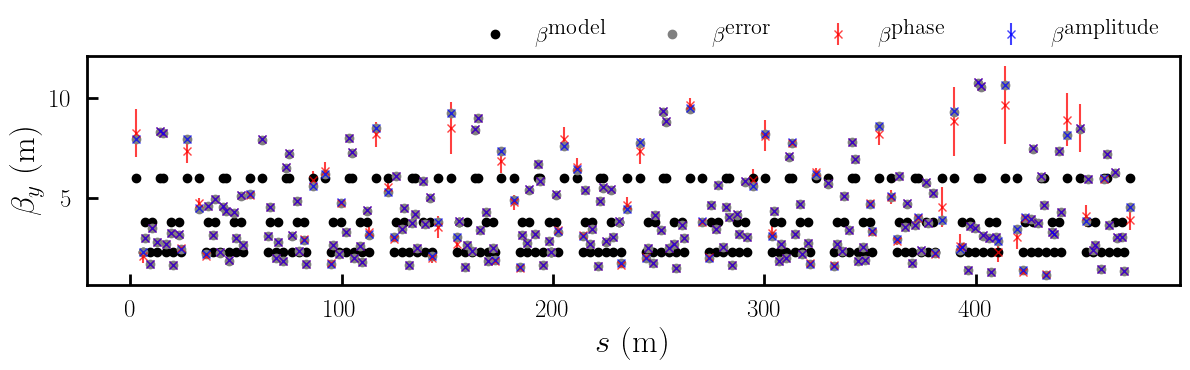

In [91]:
_, ax = plt.subplots(figsize=(12, 4))

ax.errorbar(model.time[model.monitor_index], model.by[model.monitor_index], fmt=' ', color='black', marker='o', ms=6, label=r'$\beta^\textrm{model}$')
ax.errorbar(model.time[model.monitor_index], by, fmt=' ', color='gray', marker='o', ms=6, label=r'$\beta^\textrm{error}$')
ax.errorbar(model.time[model.monitor_index], twiss.by[model.monitor_index], yerr=twiss.sigma_by[model.monitor_index], fmt=' ', color='red', marker='x', ms=6, alpha=0.75, label=r'$\beta^\textrm{phase}$')
ax.errorbar(model.time[model.monitor_index], twiss.data_amplitude['by'], yerr=twiss.data_amplitude['sigma_by'], fmt=' ', color='blue', marker='x', ms=6, alpha=0.75, label=r'$\beta^\textrm{amplitude}$')

ax.set_xlabel(r'$s ~ \textrm{(m)}$', fontsize=24)
ax.set_ylabel(r'$\beta_y ~ \textrm{(m)}$', fontsize=24)

ax.tick_params(width=2, labelsize=18)
ax.tick_params(axis='x', length=8, direction='in')
ax.tick_params(axis='y', length=8, direction='in')

ax.tick_params(axis='x', pad=10)
ax.tick_params(axis='y', pad=10)

ax.legend(loc=1, ncol=4, frameon=False, prop={'size': 16}, bbox_to_anchor=(1, 1.25))

plt.setp(ax.spines.values(), linewidth=2.0)

plt.tight_layout()
plt.savefig("./beta_y.png", format="png", dpi=300, bbox_inches='tight')
plt.show()

## Twiss from invariant fit

In [30]:
%%time

# Estimate twiss from invariant fit

count = 8

data = twiss.get_twiss_from_data(1,                # -- first turn
                                 128,              # -- total number of turns, orbits are computed for (start, start + total)
                                 parametric_normal,# -- normalization
                                 model.matrix,     # -- transport matrix generator
                                 twiss=None,       # -- initial twiss for each location or None (use model values)
                                 method='lstsq',   # -- momenta computation method
                                 limit=1,          # -- range limit or direction/shift
                                 product=True,     # -- flag to use product objective
                                 jacobian=False,   # -- flag to use objective jacobian
                                 count=count,      # -- number of samples
                                 fraction=0.75,    # -- sample length fraction
                                 ix=None,          # -- ix invariant value
                                 iy=None,          # -- iy invariant value  (both should present for fixed fit)
                                 n_jobs=4,         # -- number of parallel jobs (loop over samples)
                                 verbose=False)    # -- verbose flag

CPU times: user 9min 48s, sys: 16 s, total: 10min 4s
Wall time: 12min


In [31]:
# Process fitted invariants

ix_out = data[:, 0, 0]
iy_out = data[:, 0, 1]

sigma_ix = data[:, 1, 0]
sigma_iy = data[:, 1, 1]

invariant = twiss.get_invariant(ix_out, iy_out, sigma_ix, sigma_iy)

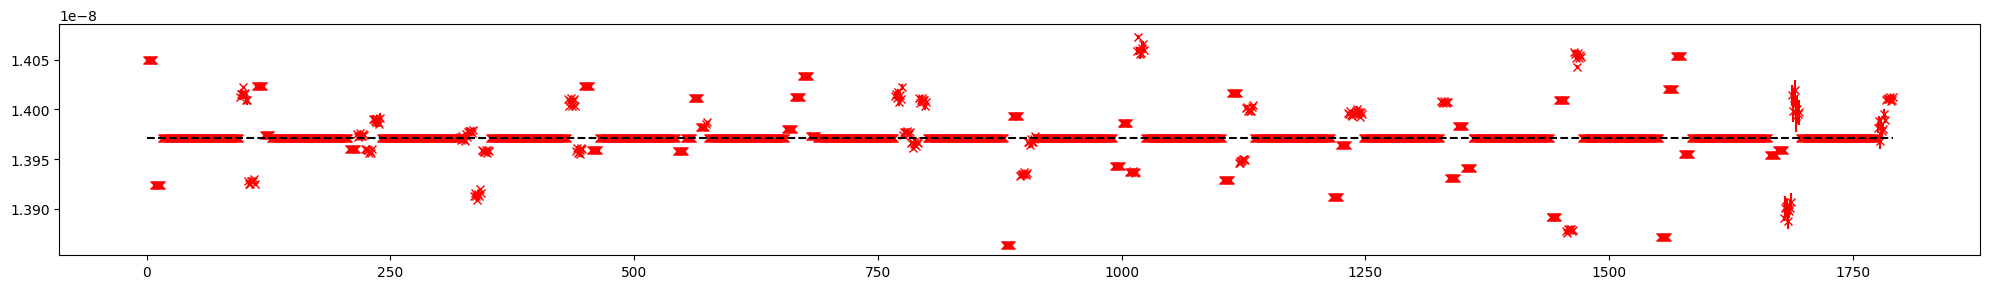

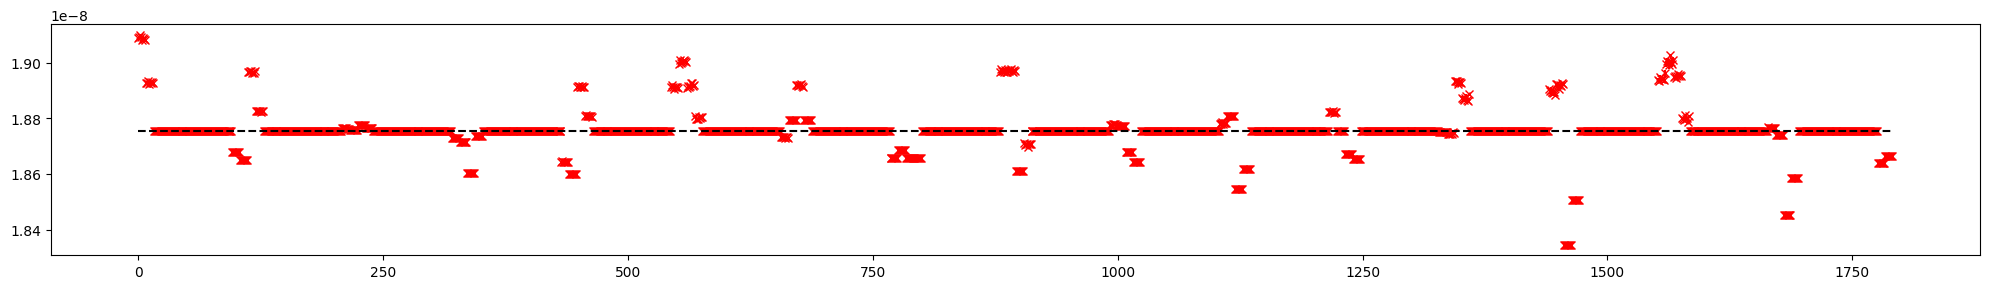

In [32]:
# Plot invariants for each sample in each signal

plt.figure(figsize=(20, 3))
plt.errorbar(range(count*model.monitor_count), ix_out.flatten().cpu().numpy(), yerr=sigma_ix.flatten().cpu().numpy(), fmt=' ', color='red', marker='x', zorder=0)
plt.hlines(ix.mean(), 0, count*model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(count*model.monitor_count), iy_out.flatten().cpu().numpy(), yerr=sigma_iy.flatten().cpu().numpy(), fmt=' ', color='red', marker='x', zorder=0)
plt.hlines(iy.mean(), 0, count*model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.tight_layout()
plt.show()

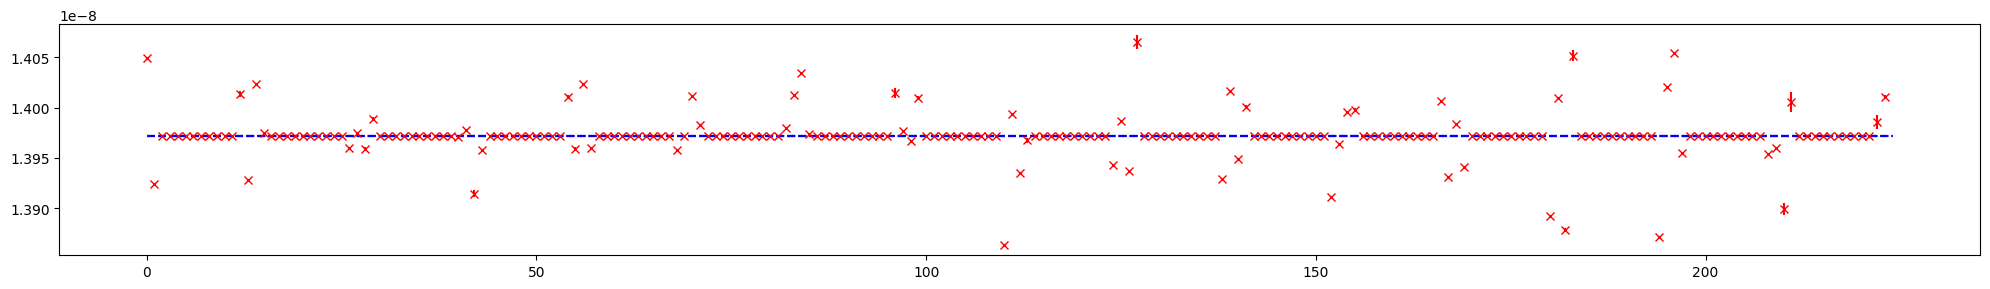

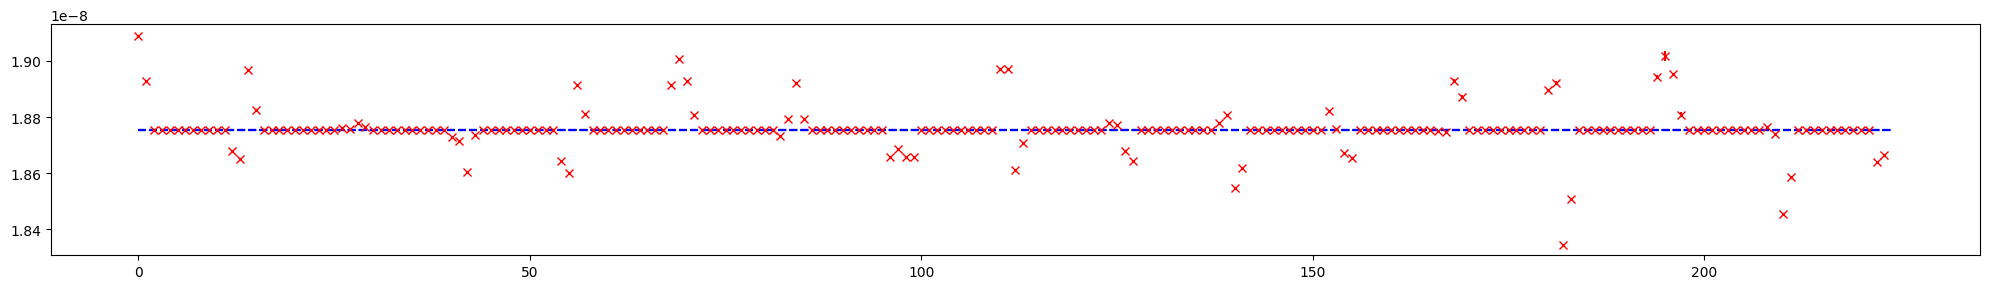

tensor(1.3972e-08, dtype=torch.float64)
tensor(1.3910e-08, dtype=torch.float64)
tensor(1.3972e-08, dtype=torch.float64)
tensor(1.3972e-08, dtype=torch.float64)

tensor(1.8755e-08, dtype=torch.float64)
tensor(1.8725e-08, dtype=torch.float64)
tensor(1.8755e-08, dtype=torch.float64)
tensor(1.8757e-08, dtype=torch.float64)



In [33]:
# Plot invariants for each monitor

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), invariant['ix_center'].flatten().cpu().numpy(), yerr=invariant['ix_spread'].flatten().cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(ix.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([invariant['ix_value'] - invariant['ix_error'], invariant['ix_value'], invariant['ix_value'] + invariant['ix_error']], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), invariant['iy_center'].flatten().cpu().numpy(), yerr=invariant['iy_spread'].flatten().cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(iy.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([invariant['iy_value'] - invariant['iy_error'], invariant['iy_value'], invariant['iy_value'] + invariant['iy_error']], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

print(ix.mean())
print(twiss.action['center_jx'])
print(invariant['ix_value'])
print(ix_out.mean())
print()

print(iy.mean())
print(twiss.action['center_jy'])
print(invariant['iy_value'])
print(iy_out.mean())
print()

In [34]:
# Process twiss

value_n11 = data[:, 0, 2]
error_n11 = data[:, 1, 2]

value_n33 = data[:, 0, 3]
error_n33 = data[:, 1, 3]

value_n21 = data[:, 0, 4]
error_n21 = data[:, 1, 4]

value_n43 = data[:, 0, 5]
error_n43 = data[:, 1, 5]

value_n13 = data[:, 0, 6]
error_n13 = data[:, 1, 6]

value_n31 = data[:, 0, 7]
error_n31 = data[:, 1, 7]

value_n14 = data[:, 0, 8]
error_n14 = data[:, 1, 8]

value_n41 = data[:, 0, 9]
error_n41 = data[:, 1, 9]

value_n11, error_n11 = twiss.process(value_n11, error_n11)
value_n33, error_n33 = twiss.process(value_n33, error_n33)
value_n21, error_n21 = twiss.process(value_n21, error_n21)
value_n43, error_n43 = twiss.process(value_n43, error_n43)
value_n13, error_n13 = twiss.process(value_n13, error_n13)
value_n31, error_n31 = twiss.process(value_n31, error_n31)
value_n14, error_n14 = twiss.process(value_n14, error_n14)
value_n41, error_n41 = twiss.process(value_n41, error_n41)

value = torch.stack([value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41]).T
error = torch.stack([error_n11, error_n33, error_n21, error_n43, error_n13, error_n31, error_n14, error_n41]).T

cs_value, cs_error = [], []

for value_loc, error_loc in zip(value, error):
    table = value_loc.reshape(-1, 1) + error_loc.reshape(-1, 1)*torch.randn(1024, dtype=dtype, device=device)
    table = torch.stack([parametric_normal(*free) for free in table.T])
    table = normal_to_wolski(table)
    table = torch.stack([wolski_to_cs(w) for w in table]).T
    cs_value.append(table.mean(-1))
    cs_error.append(table.std(-1))
    
cs_value = torch.stack(cs_value)
cs_error = torch.stack(cs_error)

value_ax, value_bx, value_ay, value_by = cs_value.T
error_ax, error_bx, error_ay, error_by = cs_error.T

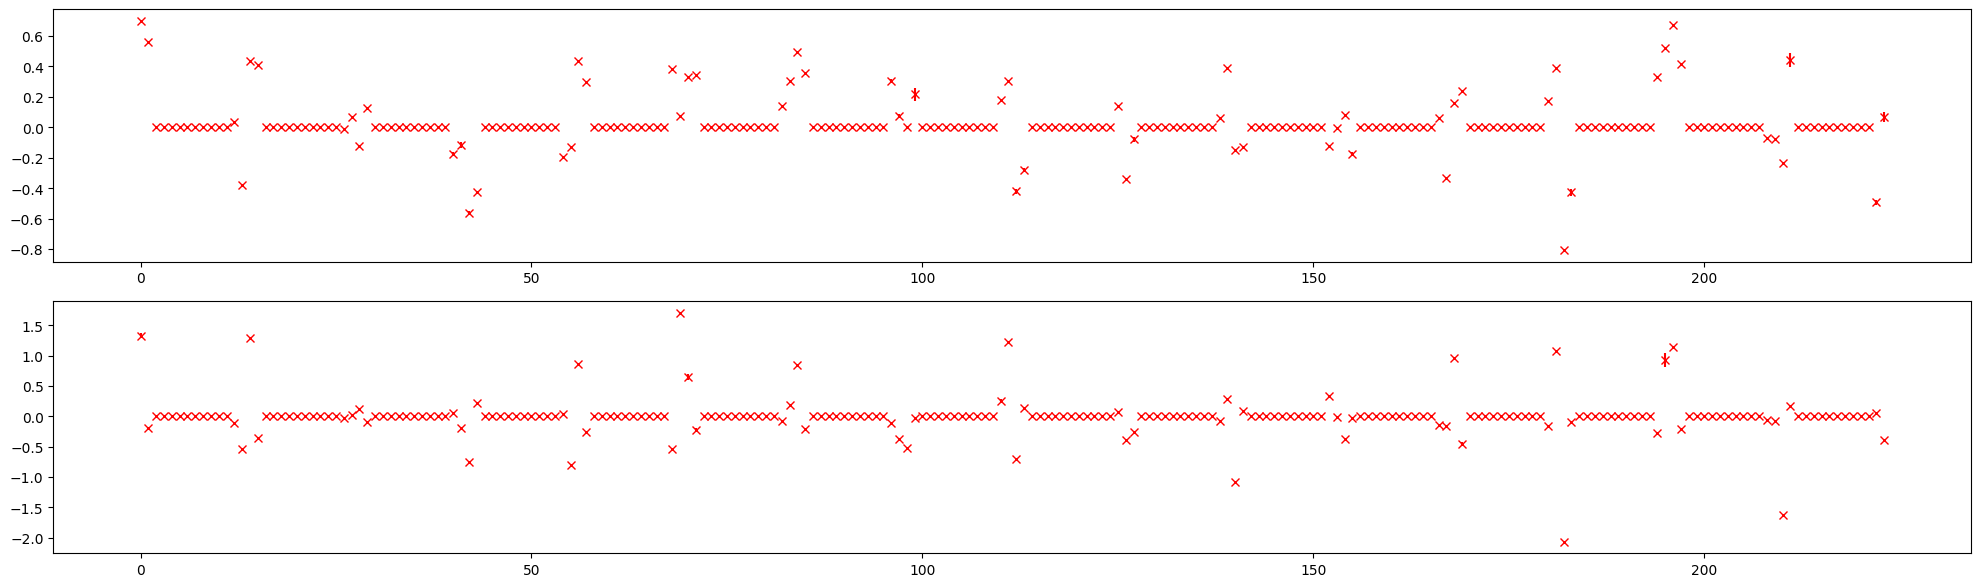

tensor(0.1733, dtype=torch.float64)
tensor(0.3443, dtype=torch.float64)



In [35]:
# Compare beta function values

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((value_bx - bx)/bx).cpu().numpy(), yerr=100/bx*error_bx.cpu().numpy(), fmt=' ', marker='x', color='red')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((value_by - by)/by).cpu().numpy(), yerr=100/by*error_by.cpu().numpy(), fmt=' ', marker='x', color='red')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((value_bx - bx)/bx)))
print(root_mean_square(100*((value_by - by)/by)))
print()

In [36]:
# Estimate momenta at each monitor location

orbit = []
for location in range(model.monitor_count):
    orbit.append(twiss.get_momenta_lstsq(1, 128, location, 1, model.matrix))
orbit = torch.stack(orbit)
print(orbit.shape)

torch.Size([224, 4, 128])


In [37]:
# Use measured twiss to estimate invariants

s11, s33, s21, s43, s13, s31, s14, s41 = value.T
e11, e33, e21, e43, e13, e31, e14, e41 = error.T

BAG_IX = []
BAG_IY = []

for location in range(model.monitor_count):
    
    BAG_IX_MONITOR = []
    BAG_IY_MONITOR = []
    
    for _ in range(128):
        
        m11 = s11[location] + e11[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m33 = s33[location] + e33[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m21 = s21[location] + e21[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m43 = s43[location] + e43[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m13 = s13[location] + e13[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m31 = s31[location] + e31[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m14 = s14[location] + e14[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m41 = s41[location] + e41[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        
        normal = parametric_normal(m11, m33, m21, m43, m13, m31, m14, m41)
        
        QX, PX, QY, PY = normal.inverse() @ orbit[location]
        IX, IY = 0.5*(QX**2 + PX**2), 0.5*(QY**2 + PY**2)
        
        BAG_IX_MONITOR.append(IX)
        BAG_IY_MONITOR.append(IY)
        
    BAG_IX.append(BAG_IX_MONITOR)
    BAG_IY.append(BAG_IY_MONITOR)

BAG_IX = torch.stack([torch.stack(IX) for IX in BAG_IX]).reshape(model.monitor_count, -1)
BAG_IY = torch.stack([torch.stack(IY) for IY in BAG_IY]).reshape(model.monitor_count, -1)

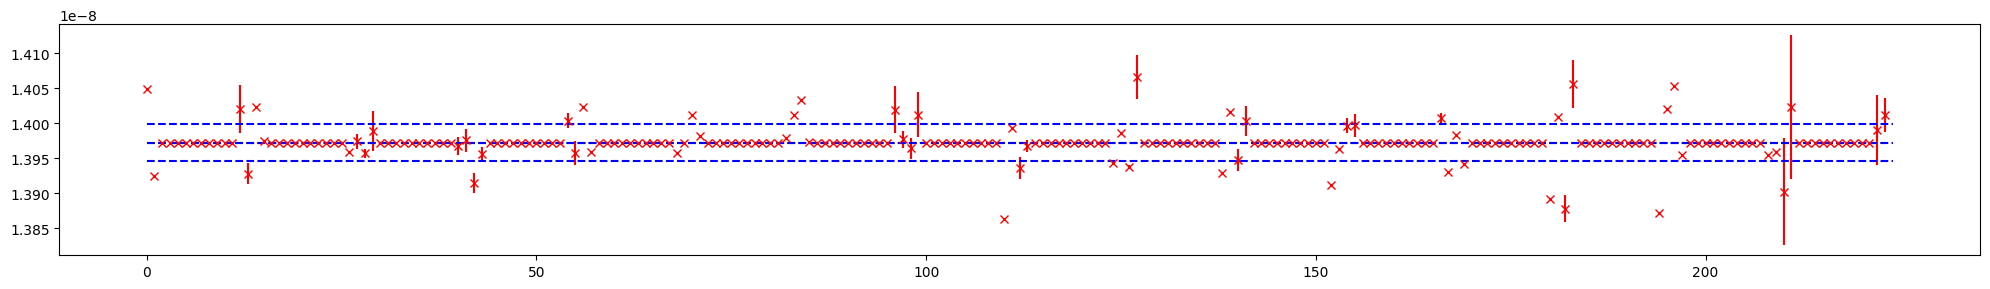

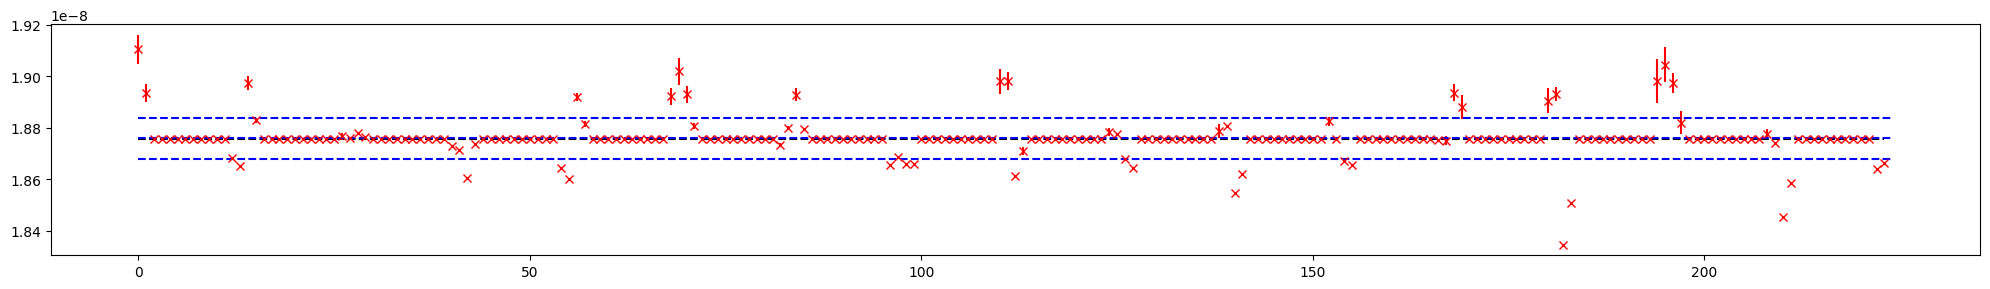

tensor(1.3972e-08, dtype=torch.float64)
tensor(1.3910e-08, dtype=torch.float64)
tensor(1.3972e-08, dtype=torch.float64)
tensor(1.3972e-08, dtype=torch.float64)
tensor(1.3972e-08, dtype=torch.float64)

tensor(1.8755e-08, dtype=torch.float64)
tensor(1.8725e-08, dtype=torch.float64)
tensor(1.8755e-08, dtype=torch.float64)
tensor(1.8757e-08, dtype=torch.float64)
tensor(1.8758e-08, dtype=torch.float64)



In [38]:
# Plot invariants for each monitor

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), BAG_IX.mean(-1).flatten().cpu().numpy(), yerr=BAG_IX.std(-1).cpu().numpy(), fmt=' ', color='red', marker='x')

plt.hlines(ix.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([BAG_IX.mean() - BAG_IX.std(), BAG_IX.mean(), BAG_IX.mean() + BAG_IX.std()], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), BAG_IY.mean(-1).flatten().cpu().numpy(), yerr=BAG_IY.std(-1).cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(iy.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([BAG_IY.mean() - BAG_IY.std(), BAG_IY.mean(), BAG_IY.mean() + BAG_IY.std()], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

print(ix.mean())
print(twiss.action['center_jx'])
print(invariant['ix_value'])
print(ix_out.mean())
print(BAG_IX.mean())
print()

print(iy.mean())
print(twiss.action['center_jy'])
print(invariant['iy_value'])
print(iy_out.mean())
print(BAG_IY.mean())
print()

In [39]:
%%time

# Estimate twiss from invariant fit (fixed invariants)

count = 8

data = twiss.get_twiss_from_data(1,                # -- first turn
                                 128,              # -- total number of turns, orbits are computed for (start, start + total)
                                 parametric_normal,# -- normalization
                                 model.matrix,     # -- transport matrix generator
                                 twiss=None,       # -- initial twiss for each location or None (use model values)
                                 method='lstsq',   # -- momenta computation method
                                 limit=1,          # -- range limit or direction/shift
                                 product=True,     # -- flag to use product objective
                                 jacobian=False,   # -- flag to use objective jacobian
                                 count=count,      # -- number of samples
                                 fraction=0.75,    # -- sample length fraction
                                 ix=BAG_IX.mean(), # -- ix invariant value
                                 iy=BAG_IY.mean(), # -- iy invariant value  (both should present for fixed fit)
                                 n_jobs=4,         # -- number of parallel jobs (loop over samples)
                                 verbose=False)    # -- verbose flag

CPU times: user 9min 50s, sys: 15.8 s, total: 10min 6s
Wall time: 11min 59s


In [40]:
# Process twiss

value_n11 = data[:, 0, 0]
error_n11 = data[:, 1, 0]

value_n33 = data[:, 0, 1]
error_n33 = data[:, 1, 1]

value_n21 = data[:, 0, 2]
error_n21 = data[:, 1, 2]

value_n43 = data[:, 0, 3]
error_n43 = data[:, 1, 3]

value_n13 = data[:, 0, 4]
error_n13 = data[:, 1, 4]

value_n31 = data[:, 0, 5]
error_n31 = data[:, 1, 5]

value_n14 = data[:, 0, 6]
error_n14 = data[:, 1, 6]

value_n41 = data[:, 0, 7]
error_n41 = data[:, 1, 7]

value_n11, error_n11 = twiss.process(value_n11, error_n11)
value_n33, error_n33 = twiss.process(value_n33, error_n33)
value_n21, error_n21 = twiss.process(value_n21, error_n21)
value_n43, error_n43 = twiss.process(value_n43, error_n43)
value_n13, error_n13 = twiss.process(value_n13, error_n13)
value_n31, error_n31 = twiss.process(value_n31, error_n31)
value_n14, error_n14 = twiss.process(value_n14, error_n14)
value_n41, error_n41 = twiss.process(value_n41, error_n41)

value = torch.stack([value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41]).T
error = torch.stack([error_n11, error_n33, error_n21, error_n43, error_n13, error_n31, error_n14, error_n41]).T

cs_value, cs_error = [], []

for value_loc, error_loc in zip(value, error):
    table = value_loc.reshape(-1, 1) + error_loc.reshape(-1, 1)*torch.randn(1024, dtype=dtype, device=device)
    table = torch.stack([parametric_normal(*free) for free in table.T])
    table = normal_to_wolski(table)
    table = torch.stack([wolski_to_cs(w) for w in table]).T
    cs_value.append(table.mean(-1))
    cs_error.append(table.std(-1))
    
cs_value = torch.stack(cs_value)
cs_error = torch.stack(cs_error)

value_ax, value_bx, value_ay, value_by = cs_value.T
error_ax, error_bx, error_ay, error_by = cs_error.T

In [41]:
print(root_mean_square(100*((twiss.bx[model.monitor_index] - bx)/bx)))
print(root_mean_square(100*((twiss.by[model.monitor_index] - by)/by)))
print()

tensor(1.1392, dtype=torch.float64)
tensor(3.1780, dtype=torch.float64)



In [42]:
print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx)/bx)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by)/by)))
print()

tensor(0.2649, dtype=torch.float64)
tensor(0.3112, dtype=torch.float64)



In [43]:
print(root_mean_square(100*((value_bx - bx)/bx)))
print(root_mean_square(100*((value_by - by)/by)))
print()

tensor(0.1806, dtype=torch.float64)
tensor(0.3545, dtype=torch.float64)



In [44]:
print(root_mean_square(1*((twiss.ax[model.monitor_index] - Ax))))
print(root_mean_square(1*((twiss.ay[model.monitor_index] - Ay))))
print()

tensor(0.0629, dtype=torch.float64)
tensor(0.0339, dtype=torch.float64)



In [45]:
print(root_mean_square(1*((value_ax - Ax))))
print(root_mean_square(1*((value_ay - Ay))))
print()

tensor(0.0260, dtype=torch.float64)
tensor(0.0086, dtype=torch.float64)



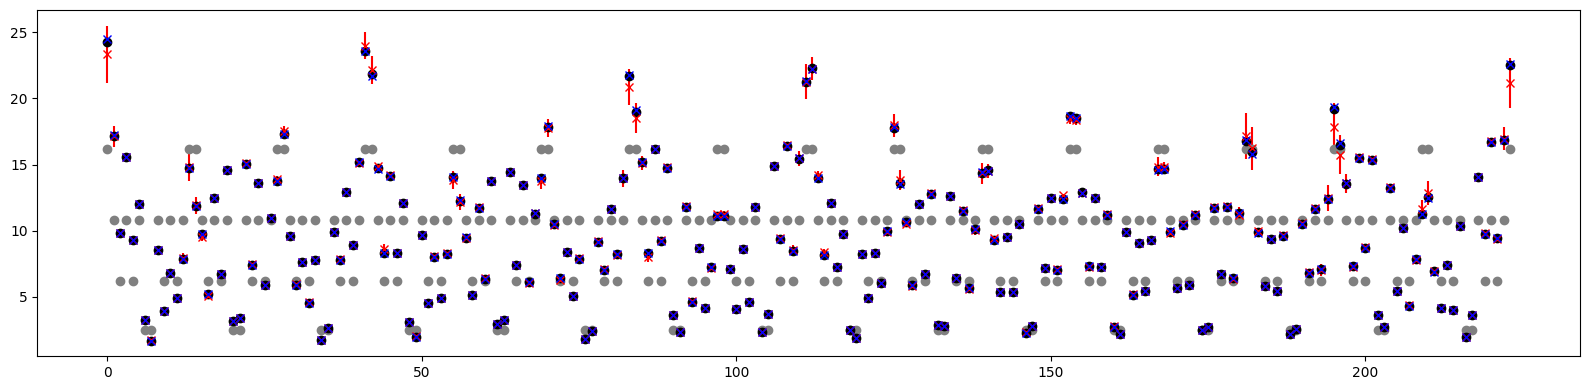

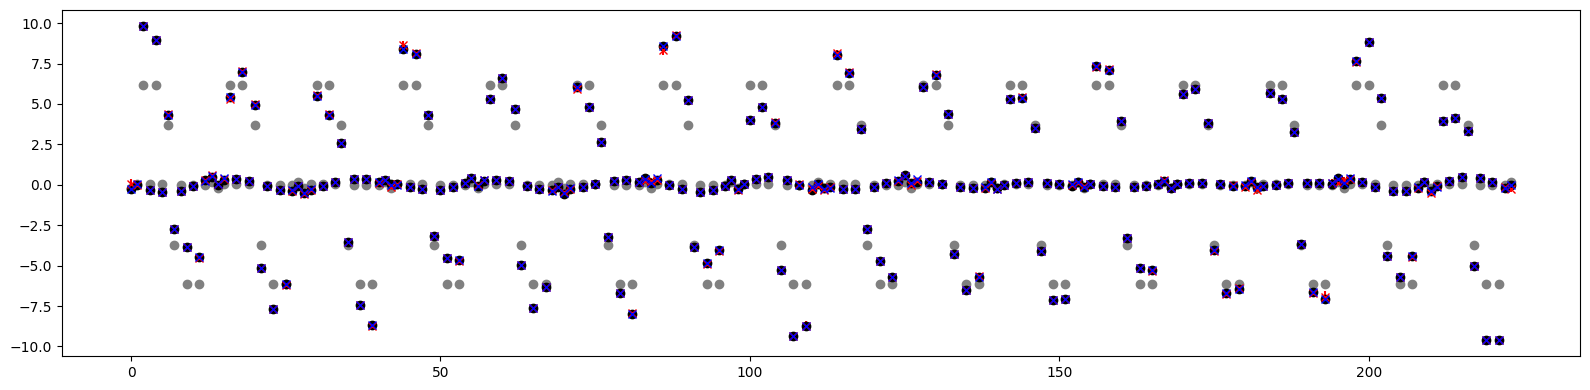

In [46]:
# FIG-2: MEASURED VS HIDDEN TWISS FROM AMPLITUDE AND PHASE AND FIT (ALPHA AND BETA)
# |beta|beta|
# |alfa|alfa|

plt.figure(figsize=(16, 4))
plt.errorbar(range(model.monitor_count), model.bx[model.monitor_index], fmt=' ', color='gray', marker='o', ms=6)
plt.errorbar(range(model.monitor_count), bx, fmt=' ', color='black', marker='o', ms=6)
plt.errorbar(range(model.monitor_count), twiss.bx[model.monitor_index], yerr=twiss.sigma_bx[model.monitor_index], fmt=' ', color='red', marker='x', ms=6)
plt.errorbar(range(model.monitor_count), value_bx, yerr=error_bx, fmt=' ', color='blue', marker='x', ms=6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 4))
plt.errorbar(range(model.monitor_count), model.ax[model.monitor_index], fmt=' ', color='gray', marker='o', ms=6)
plt.errorbar(range(model.monitor_count), Ax, fmt=' ', color='black', marker='o', ms=6)
plt.errorbar(range(model.monitor_count), twiss.ax[model.monitor_index], yerr=twiss.sigma_ax[model.monitor_index], fmt=' ', color='red', marker='x', ms=6)
plt.errorbar(range(model.monitor_count), value_ax, yerr=error_ax, fmt=' ', color='blue', marker='x', ms=6)
plt.tight_layout()
plt.show()

In [97]:
print(f'{100*root_mean_square((model.bx[model.monitor_index] - bx)/model.bx[model.monitor_index]).item():.2f}')
print(f'{100*root_mean_square((model.by[model.monitor_index] - by)/model.by[model.monitor_index]).item():.2f}')

25.07
34.85


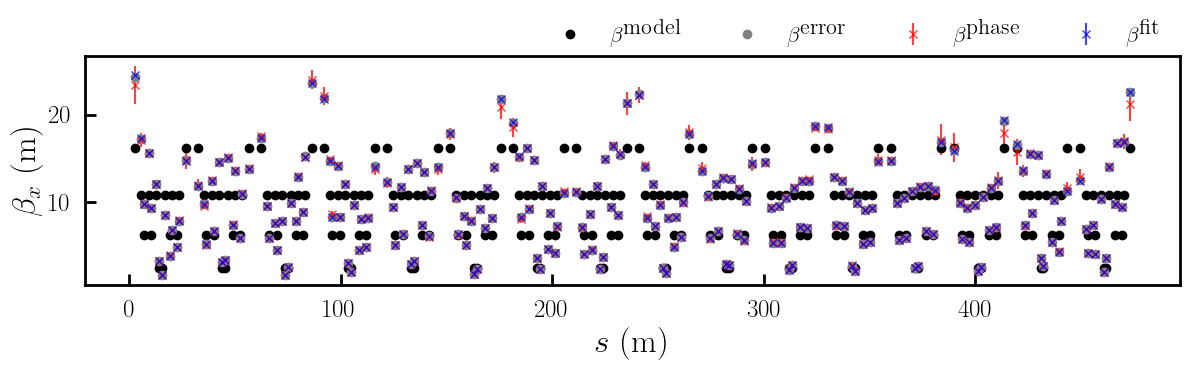

In [92]:
_, ax = plt.subplots(figsize=(12, 4))

ax.errorbar(model.time[model.monitor_index], model.bx[model.monitor_index], fmt=' ', color='black', marker='o', ms=6, label=r'$\beta^\textrm{model}$')
ax.errorbar(model.time[model.monitor_index], bx, fmt=' ', color='gray', marker='o', ms=6, label=r'$\beta^\textrm{error}$')
ax.errorbar(model.time[model.monitor_index], twiss.bx[model.monitor_index], yerr=twiss.sigma_bx[model.monitor_index], fmt=' ', color='red', marker='x', ms=6, alpha=0.75, label=r'$\beta^\textrm{phase}$')
ax.errorbar(model.time[model.monitor_index], value_bx, yerr=error_bx, fmt=' ', color='blue', marker='x', ms=6, alpha=0.75, label=r'$\beta^\textrm{fit}$')

ax.set_xlabel(r'$s ~ \textrm{(m)}$', fontsize=24)
ax.set_ylabel(r'$\beta_x ~ \textrm{(m)}$', fontsize=24)

ax.tick_params(width=2, labelsize=18)
ax.tick_params(axis='x', length=8, direction='in')
ax.tick_params(axis='y', length=8, direction='in')

ax.tick_params(axis='x', pad=10)
ax.tick_params(axis='y', pad=10)

ax.legend(loc=1, ncol=4, frameon=False, prop={'size': 16}, bbox_to_anchor=(1, 1.25))

plt.setp(ax.spines.values(), linewidth=2.0)

plt.tight_layout()
plt.savefig("./cb_x.png", format="png", dpi=300, bbox_inches='tight')
plt.show()

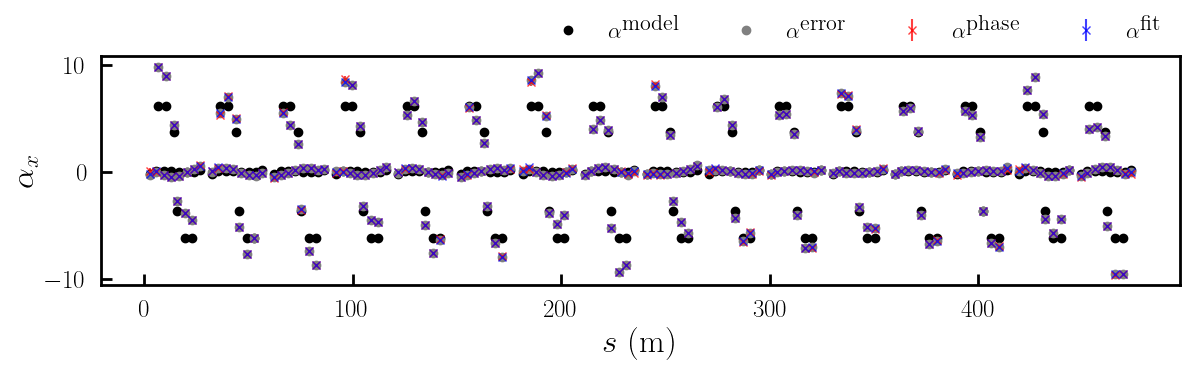

In [95]:
_, ax = plt.subplots(figsize=(12, 4))

ax.errorbar(model.time[model.monitor_index], model.ax[model.monitor_index], fmt=' ', color='black', marker='o', ms=6, label=r'$\alpha^\textrm{model}$')
ax.errorbar(model.time[model.monitor_index], Ax, fmt=' ', color='gray', marker='o', ms=6, label=r'$\alpha^\textrm{error}$')
ax.errorbar(model.time[model.monitor_index], twiss.ax[model.monitor_index], yerr=twiss.sigma_ax[model.monitor_index], fmt=' ', color='red', marker='x', ms=6, alpha=0.75, label=r'$\alpha^\textrm{phase}$')
ax.errorbar(model.time[model.monitor_index], value_ax, yerr=error_ax, fmt=' ', color='blue', marker='x', ms=6, alpha=0.75, label=r'$\alpha^\textrm{fit}$')

ax.set_xlabel(r'$s ~ \textrm{(m)}$', fontsize=24)
ax.set_ylabel(r'$\alpha_x$', fontsize=24)

ax.tick_params(width=2, labelsize=18)
ax.tick_params(axis='x', length=8, direction='in')
ax.tick_params(axis='y', length=8, direction='in')

ax.tick_params(axis='x', pad=10)
ax.tick_params(axis='y', pad=10)

ax.legend(loc=1, ncol=4, frameon=False, prop={'size': 16}, bbox_to_anchor=(1, 1.25))

plt.setp(ax.spines.values(), linewidth=2.0)

plt.tight_layout()
plt.savefig("./ca_x.png", format="png", dpi=300, bbox_inches='tight')
plt.show()

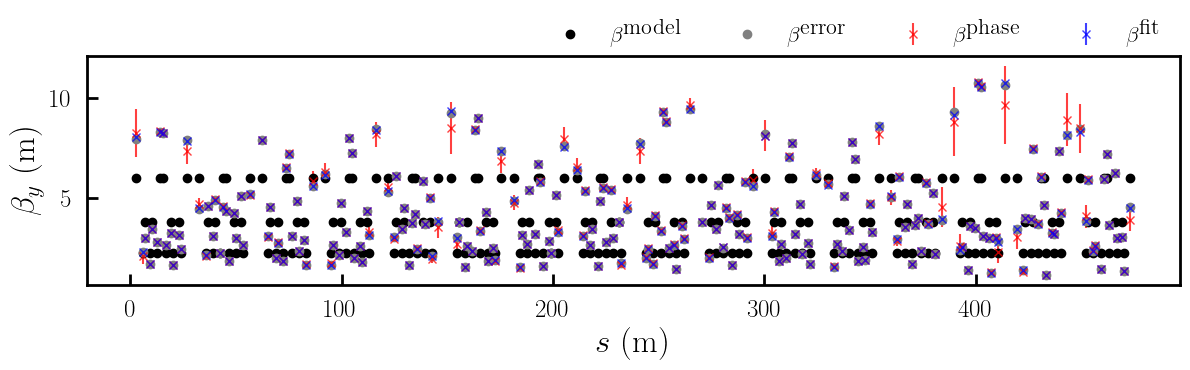

In [93]:
_, ax = plt.subplots(figsize=(12, 4))

ax.errorbar(model.time[model.monitor_index], model.by[model.monitor_index], fmt=' ', color='black', marker='o', ms=6, label=r'$\beta^\textrm{model}$')
ax.errorbar(model.time[model.monitor_index], by, fmt=' ', color='gray', marker='o', ms=6, label=r'$\beta^\textrm{error}$')
ax.errorbar(model.time[model.monitor_index], twiss.by[model.monitor_index], yerr=twiss.sigma_by[model.monitor_index], fmt=' ', color='red', marker='x', ms=6, alpha=0.75, label=r'$\beta^\textrm{phase}$')
ax.errorbar(model.time[model.monitor_index], value_by, yerr=error_by, fmt=' ', color='blue', marker='x', ms=6, alpha=0.75, label=r'$\beta^\textrm{fit}$')

ax.set_xlabel(r'$s ~ \textrm{(m)}$', fontsize=24)
ax.set_ylabel(r'$\beta_y ~ \textrm{(m)}$', fontsize=24)

ax.tick_params(width=2, labelsize=18)
ax.tick_params(axis='x', length=8, direction='in')
ax.tick_params(axis='y', length=8, direction='in')

ax.tick_params(axis='x', pad=10)
ax.tick_params(axis='y', pad=10)

ax.legend(loc=1, ncol=4, frameon=False, prop={'size': 16}, bbox_to_anchor=(1, 1.25))

plt.setp(ax.spines.values(), linewidth=2.0)

plt.tight_layout()
plt.savefig("./cb_y.png", format="png", dpi=300, bbox_inches='tight')
plt.show()

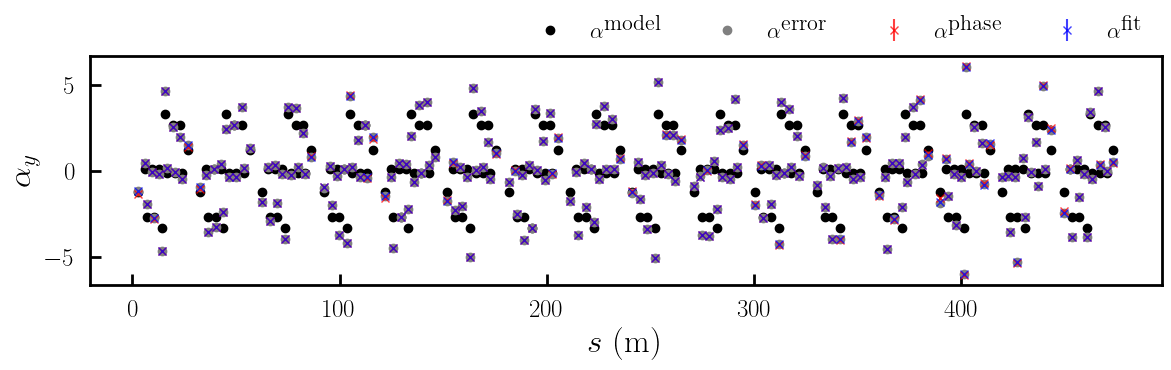

In [96]:
_, ax = plt.subplots(figsize=(12, 4))

ax.errorbar(model.time[model.monitor_index], model.ay[model.monitor_index], fmt=' ', color='black', marker='o', ms=6, label=r'$\alpha^\textrm{model}$')
ax.errorbar(model.time[model.monitor_index], Ay, fmt=' ', color='gray', marker='o', ms=6, label=r'$\alpha^\textrm{error}$')
ax.errorbar(model.time[model.monitor_index], twiss.ay[model.monitor_index], yerr=twiss.sigma_ay[model.monitor_index], fmt=' ', color='red', marker='x', ms=6, alpha=0.75, label=r'$\alpha^\textrm{phase}$')
ax.errorbar(model.time[model.monitor_index], value_ay, yerr=error_ay, fmt=' ', color='blue', marker='x', ms=6, alpha=0.75, label=r'$\alpha^\textrm{fit}$')

ax.set_xlabel(r'$s ~ \textrm{(m)}$', fontsize=24)
ax.set_ylabel(r'$\alpha_y$', fontsize=24)

ax.tick_params(width=2, labelsize=18)
ax.tick_params(axis='x', length=8, direction='in')
ax.tick_params(axis='y', length=8, direction='in')

ax.tick_params(axis='x', pad=10)
ax.tick_params(axis='y', pad=10)

ax.legend(loc=1, ncol=4, frameon=False, prop={'size': 16}, bbox_to_anchor=(1, 1.25))

plt.setp(ax.spines.values(), linewidth=2.0)

plt.tight_layout()
plt.savefig("./ca_y.png", format="png", dpi=300, bbox_inches='tight')
plt.show()